### Data description
There are 3 types of input features:

*Objective*: factual information;
*Examination*: results of medical examination;
*Subjective*: information given by the patient.

#### Features:

* Age | Objective Feature | age | int (days)
* Height | Objective Feature | height | int (cm) |
* Weight | Objective Feature | weight | float (kg) |
* Gender | Objective Feature | gender | categorical code |
* Systolic blood pressure | Examination Feature | ap_hi | int |
* Diastolic blood pressure | Examination Feature | ap_lo | int |
* Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
* Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
* Smoking | Subjective Feature | smoke | binary |
* Alcohol intake | Subjective Feature | alco | binary |
* Physical activity | Subjective Feature | active | binary |
* Presence or absence of cardiovascular diseasec (**Diagnostic**) | Target Variable | cardio | binary |

All of the dataset values were collected at the moment of medical examination.

The dataset contains 70,000 patient records with 11 features across three categories 
- bjective measurements (age, height, weight, gender), 
- examination results (systolic BP, diastolic BP, cholesterol, glucose), and 
- self-reported lifestyle factors (smoking, alcohol, physical activity). 

The target variable 'cardio' encodes presence or absence of a cardiovascular disease diagnosis."

**Limitation**
Importantly, the target variable records diagnostic outcome rather than confirmed biological disease presence. Given well-documented systematic underdiagnosis of CVD in women, a negative label cannot be assumed to reliably confirm absence of disease in female patients

In [47]:
# import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import os

data = pd.read_csv(os.path.join("data/raw/cardio_train.csv"))

# Data exploration

print(data.columns)
cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]
data["gender"] = data["gender"].replace({1: 0, 2: 1})# 0=female, 1=male

# # Null values : no null values in the dataset
# # print(data.isnull().sum())
# # Negative Values : 
# print((data < 0).sum())
# # print(pd.concat([data.head(5), data.sample(5), data.tail(5)]))

# print(data.describe(include="all").transpose())


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')


In [48]:
# ──────────────────────────────────────────
# Helper
# ──────────────────────────────────────────

feature_meta = {
    "cardio":      ("Target",        "0:No CVD, 1: CVD"),
    "gender":      ("Gender (Sex)",  "0 (female) : 1 (male)"),
    "cholesterol": ("Cholesterol",   "1:2:3"),
    "gluc":        ("Glucose",       "1:2:3"),
    "smoke":       ("Smoking",       "0:1"),
    "alco":        ("Alcohol",       "0:1"),
    "active":      ("Active",        "0:1"),
}

def compute_ratios(df):
    """Returns dict: col -> {Total, Female, Male} ratio strings."""
    female = df[df["gender"] == 0]
    male   = df[df["gender"] == 1]

    def ratio_str(subset, col):
        cats   = sorted(subset[col].dropna().unique())
        counts = subset[col].value_counts(normalize=True).sort_index() * 100
        counts = counts.reindex(cats, fill_value=0)
        return ":".join([f"{v:.1f}" for v in counts])

    return {
        col: {
            "Total":  ratio_str(df,     col),
            "Female": ratio_str(female, col),
            "Male":   ratio_str(male,   col),
        }
        for col in feature_meta
    }


# ──────────────────────────────────────────
# 1. Store BEFORE ratios
# ──────────────────────────────────────────

ratios_before = compute_ratios(data)
print(data["gender"].unique())          # should be [0, 1]
print(data["gender"].value_counts())  # before ratios_before
print(data["gender"].value_counts()) 
print(ratios_before)

[1 0]
gender
0    45530
1    24470
Name: count, dtype: int64
gender
0    45530
1    24470
Name: count, dtype: int64
{'cardio': {'Total': '50.0:50.0', 'Female': '50.3:49.7', 'Male': '49.5:50.5'}, 'gender': {'Total': '65.0:35.0', 'Female': '100.0', 'Male': '100.0'}, 'cholesterol': {'Total': '74.8:13.6:11.5', 'Female': '73.7:14.1:12.2', 'Male': '76.9:12.9:10.3'}, 'gluc': {'Total': '85.0:7.4:7.6', 'Female': '84.5:7.5:8.0', 'Male': '85.9:7.2:6.9'}, 'smoke': {'Total': '91.2:8.8', 'Female': '98.2:1.8', 'Male': '78.1:21.9'}, 'alco': {'Total': '94.6:5.4', 'Female': '97.5:2.5', 'Male': '89.4:10.6'}, 'active': {'Total': '19.6:80.4', 'Female': '19.8:80.2', 'Male': '19.3:80.7'}}


In [49]:

# Unusual blood pressure values
print("Systolic > 250 count:", data[data["ap_hi"] > 250].shape[0])
print("Diastolic > 150 count:", data[data["ap_lo"] > 150].shape[0])
print("Systolic < 70 count:", (data["ap_hi"] < 70).sum())
print("Diastolic < 40 count:", (data["ap_lo"] < 40).sum())
print("Diastolic > Systolic count:", (data["ap_lo"] > data["ap_hi"]).sum())

# Ranges for extreme values
high_sys = data[data["ap_hi"] > 250]["ap_hi"]
print("Systolic >250 range:", high_sys.min(), "to", high_sys.max())

high_dia = data[data["ap_lo"] > 150]["ap_lo"]
print("Diastolic >150 range:", high_dia.min(), "to", high_dia.max())

# Gender check
print("Gender values:", data["gender"].unique())


Systolic > 250 count: 40
Diastolic > 150 count: 975
Systolic < 70 count: 189
Diastolic < 40 count: 59
Diastolic > Systolic count: 1234
Systolic >250 range: 309 to 16020
Diastolic >150 range: 160 to 11000
Gender values: [1 0]


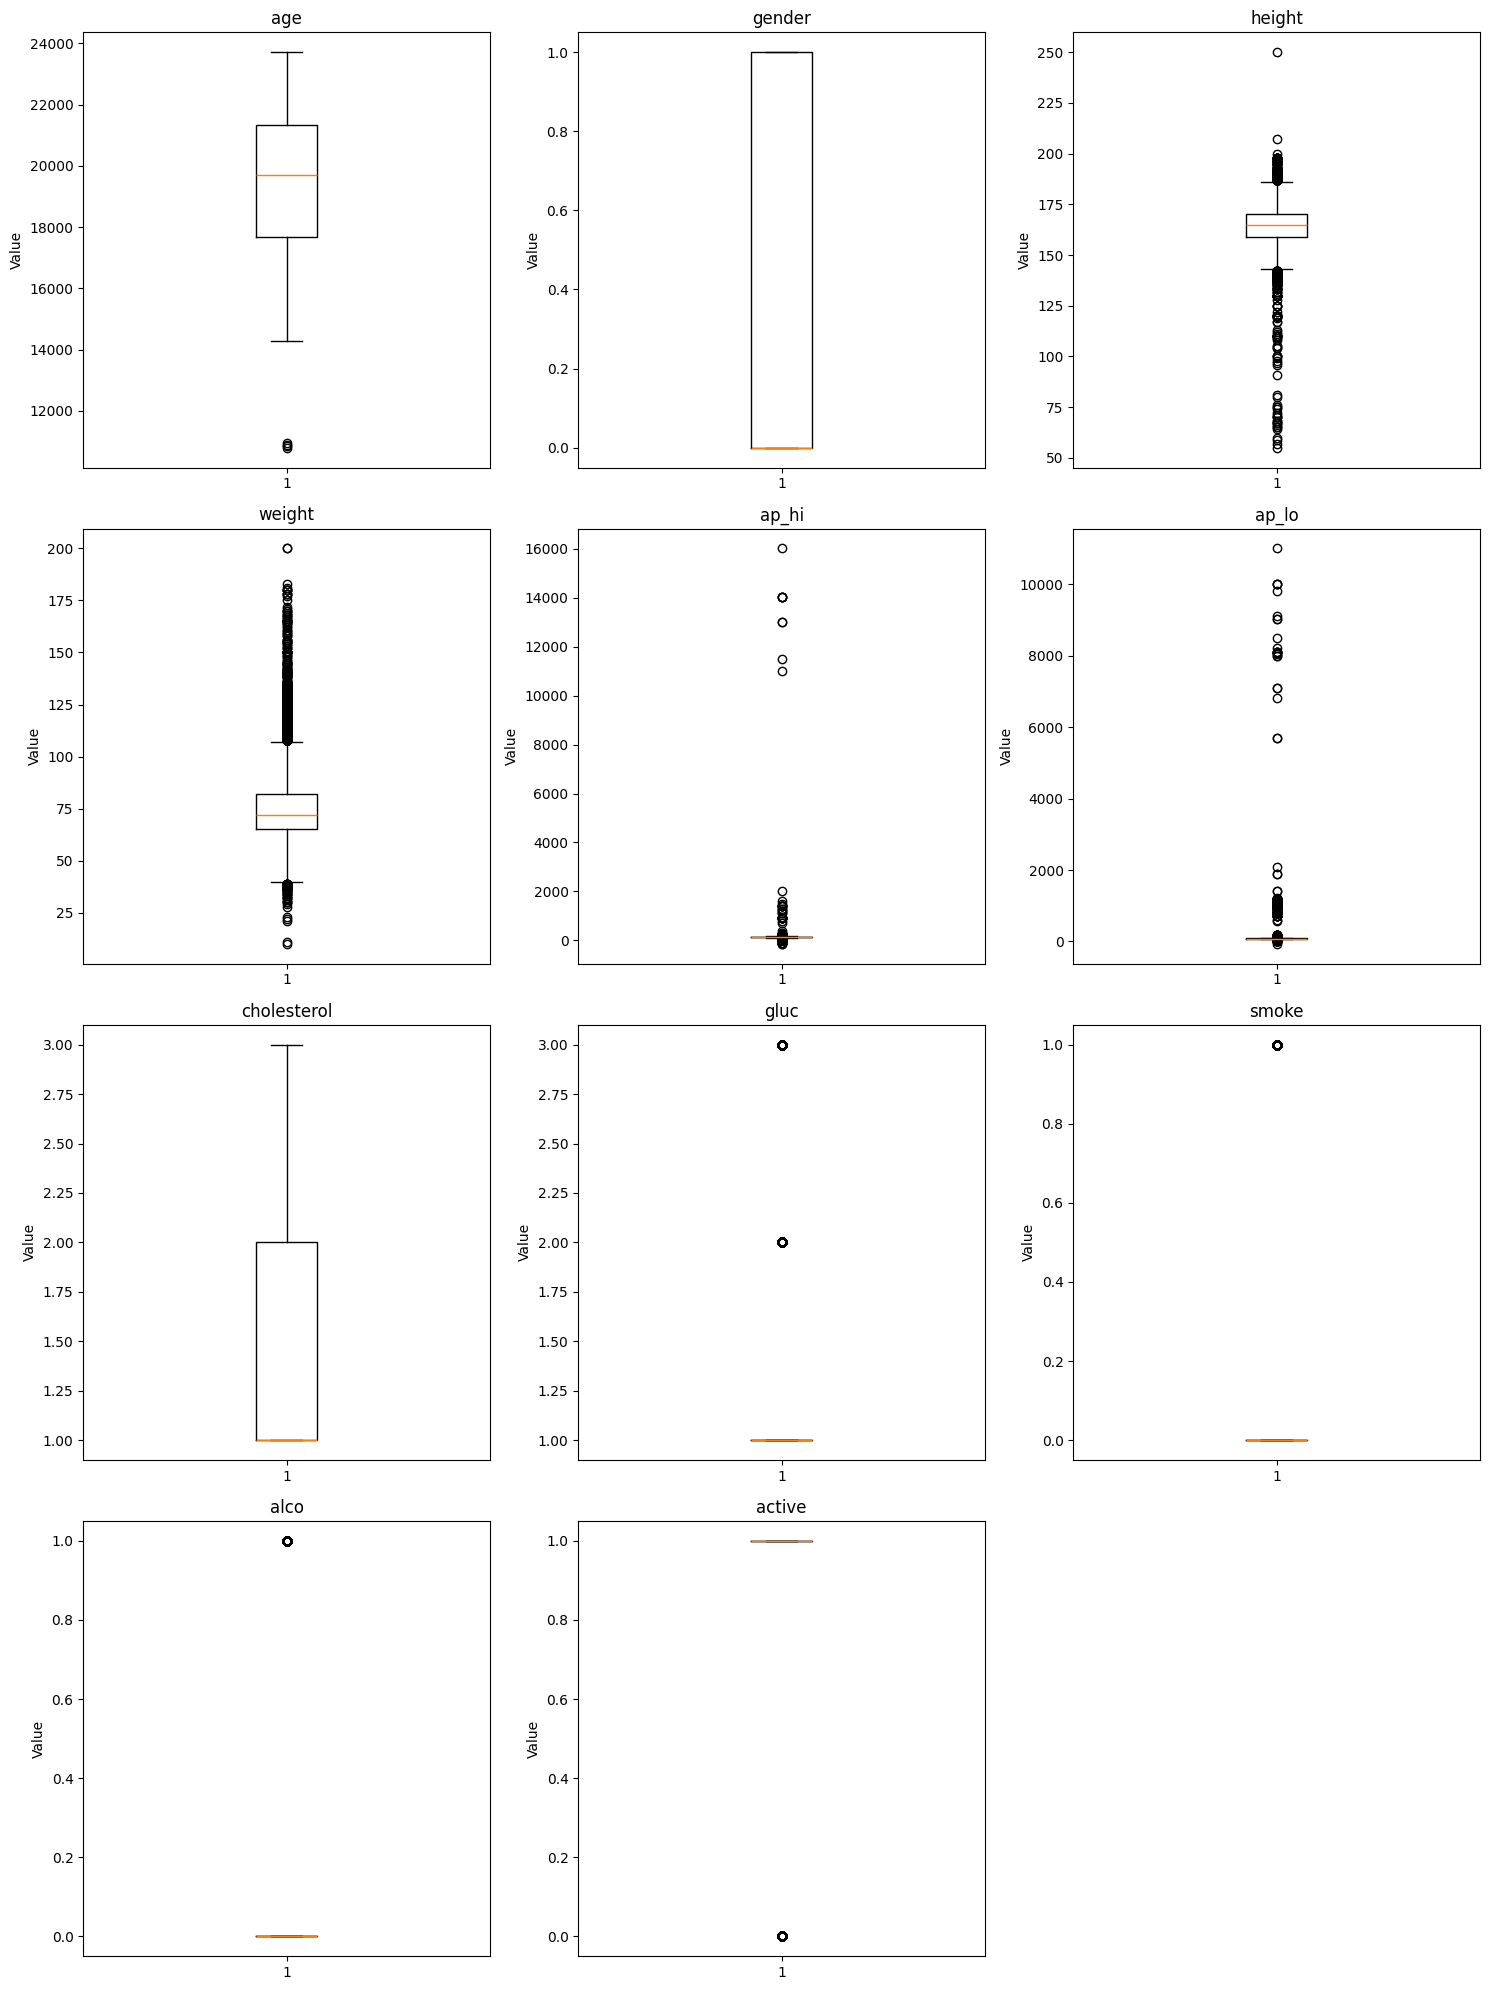

In [50]:
# Outliers - Box plots
import matplotlib.pyplot as plt
import numpy as np

# Drop target and ID (ID should not be analysed)
features = data.drop(columns=["cardio", "id"])

# Select only numeric columns
numeric_cols = features.select_dtypes(include=["int64", "float64"]).columns

# Determine grid size
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(features[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

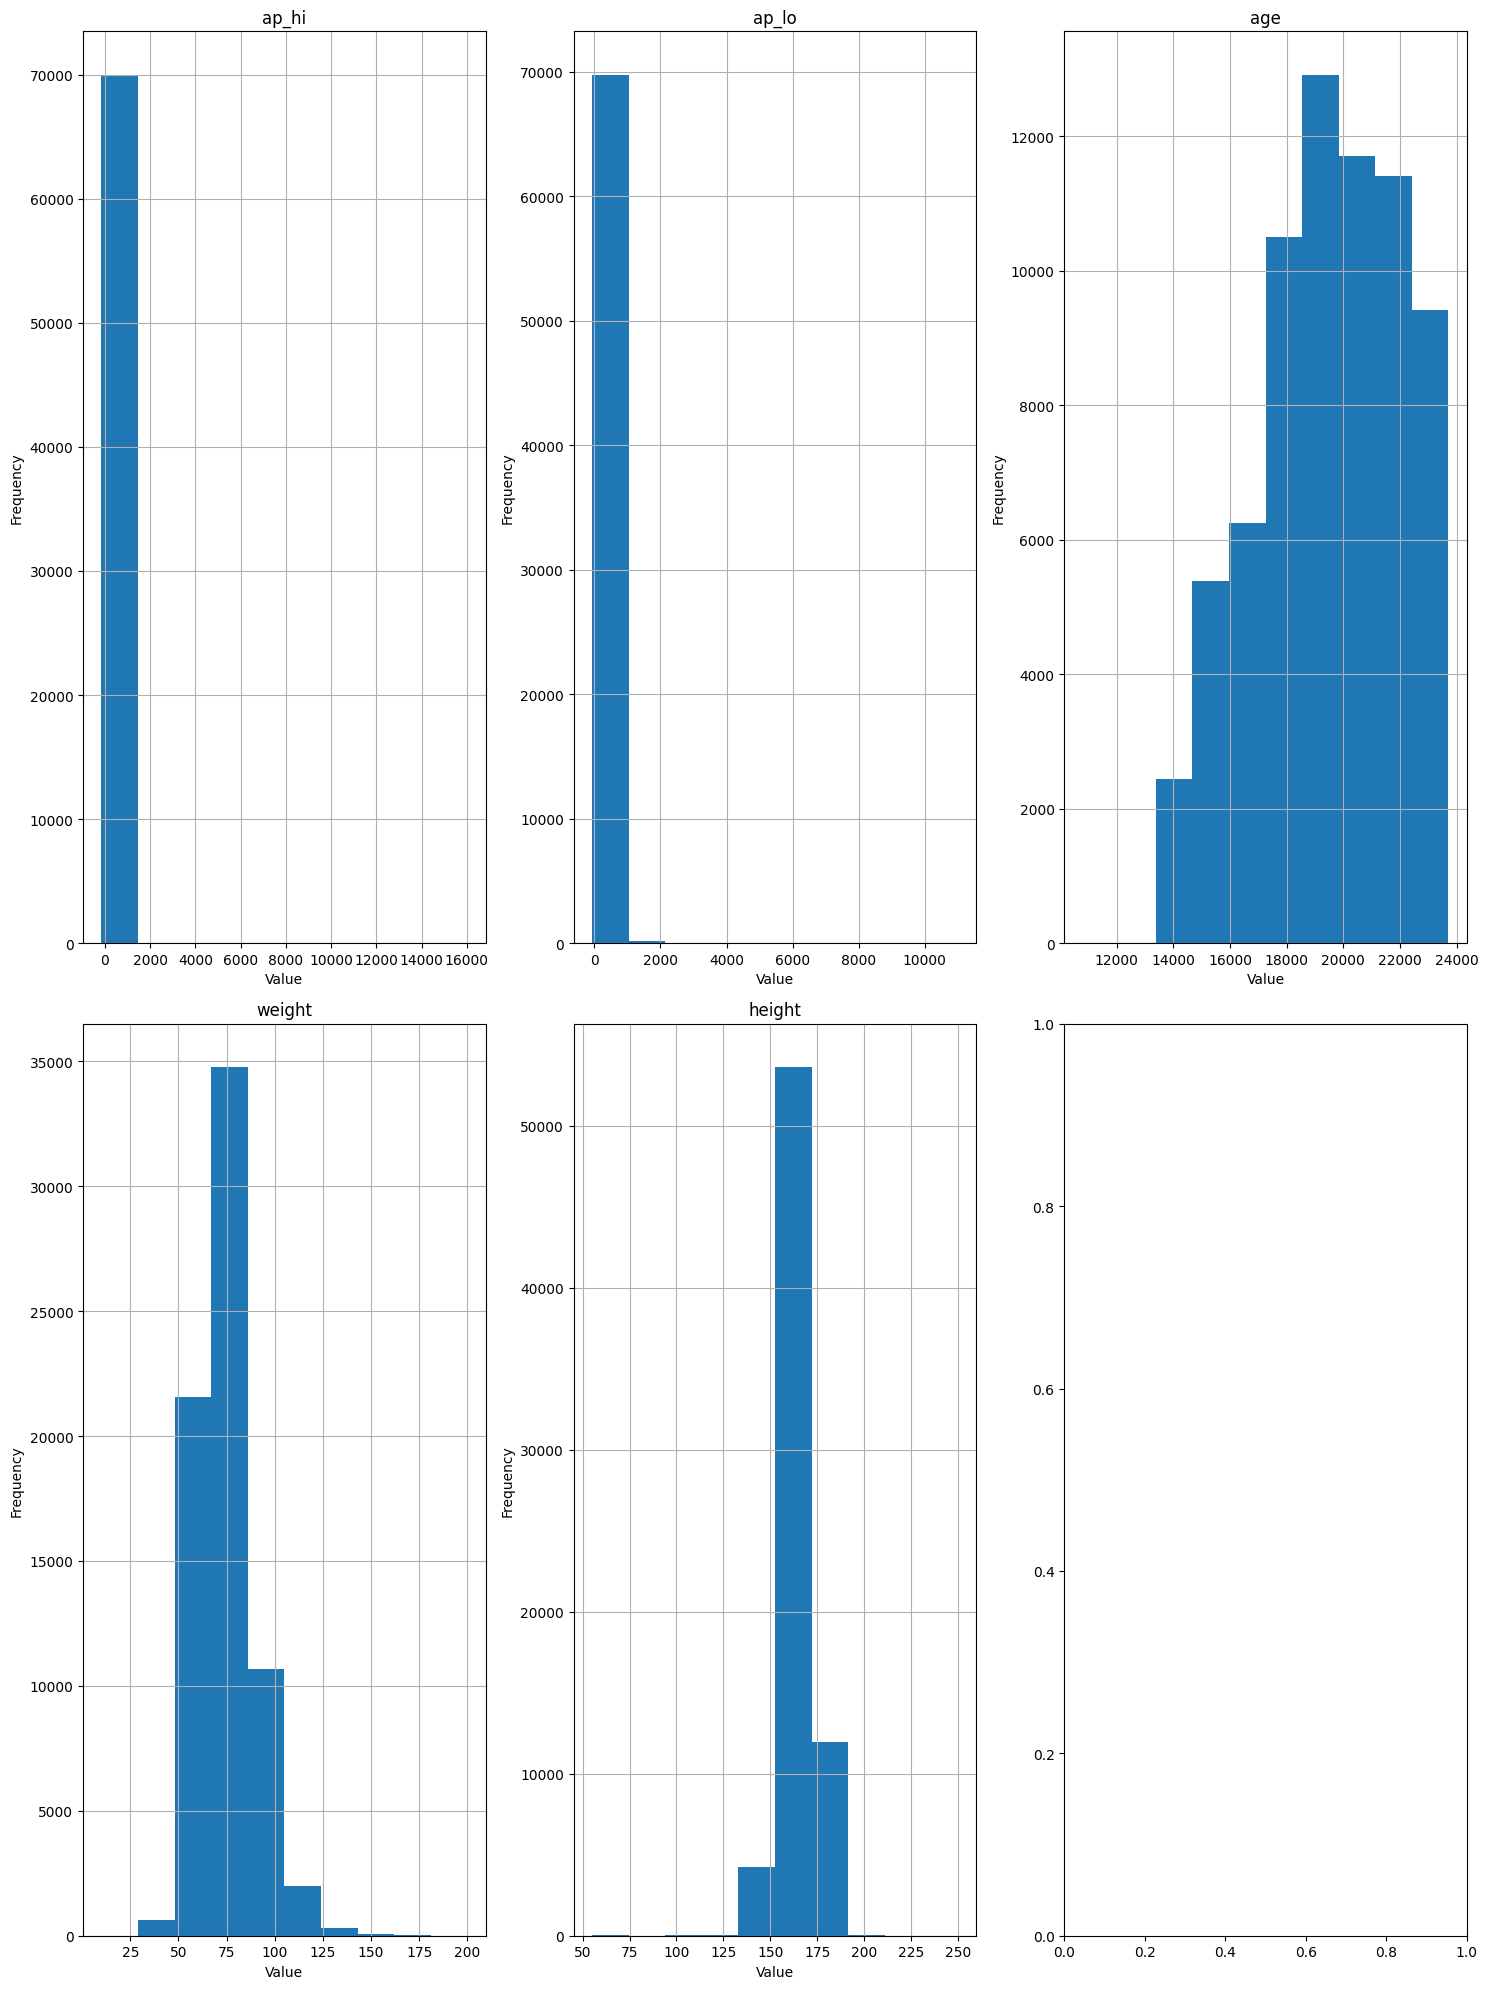

In [ ]:
numeric_cols = ["ap_hi", "ap_lo", "age", "weight", "height"]
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 20))

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data[col].hist(ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()

In [52]:

# Define outlier thresholds and filter

df = data.copy()

# --- If you already converted age to years and renamed it ---
# If your column is still "age" in days, convert first:
df["age_years"] = df["age"] / 365.25

# If you already have age in years in df["age"], then do:
# df["age_years"] = df["age"]

# 1) Create/ensure age_years exists (adjust this line to your setup)
# print("Height over 195:", (df["height"] >= 195).sum())

def apply_filter(df, mask, name):
    before = df.shape[0]
    df = df[mask].copy()
    after = df.shape[0]
    print(f"{name:35s} | kept {after:6d}/{before:6d} | removed {before - after:6d}")
    return df


# adding BMI to remove impossible cases
df["BMI"] = df["weight"] / (df["height"]/100)**2
print(df["BMI"].describe())

print((df["BMI"] > 70).sum())


count    70000.000000
mean        27.556513
std          6.091511
min          3.471784
25%         23.875115
50%         26.374068
75%         30.222222
max        298.666667
Name: BMI, dtype: float64
36


In [53]:
# --- Age filter ---
df = apply_filter(df, (df["age_years"] >= 30) & (df["age_years"] <= 65), "Age 30–65 years")

# --- Height & weight filters ---
df = apply_filter(df, (df["height"] >= 140) & (df["height"] <= 220), "Height 140–200 cm")
df = apply_filter(df, (df["weight"] >= 45) & (df["weight"] <= 200), "Weight 30–200 kg")

# --- Blood pressure filters --
df = apply_filter(df, (df["ap_hi"] >= 70) & (df["ap_hi"] <= 200), "Systolic (ap_hi) 70–200")
df = apply_filter(df, (df["ap_lo"] >= 40) & (df["ap_lo"] <= 150), "Diastolic (ap_lo) 40–150")
df = apply_filter(df, df["ap_lo"] <= df["ap_hi"], "Diastolic <= Systolic")

# --- Cholesterol & glucose allowed values ---
df = apply_filter(df, df["cholesterol"].isin([1, 2, 3]), "Cholesterol in {1,2,3}")
df = apply_filter(df, df["gluc"].isin([1, 2, 3]), "Glucose in {1,2,3}")
# Clipping height cause below 140 is very rare for adults

# --- Lifestyle & target must be binary ---
for col in ["smoke", "alco", "active", "cardio"]:
    df = apply_filter(df, df[col].isin([0, 1]), f"{col} in {{0,1}}")

df = df.drop(columns=["id", "age"])  # Drop the ID
print("\nFinal cleaned shape:", df.shape)

Age 30–65 years                     | kept  69997/ 70000 | removed      3
Height 140–200 cm                   | kept  69844/ 69997 | removed    153
Weight 30–200 kg                    | kept  69551/ 69844 | removed    293
Systolic (ap_hi) 70–200             | kept  69266/ 69551 | removed    285
Diastolic (ap_lo) 40–150            | kept  68263/ 69266 | removed   1003
Diastolic <= Systolic               | kept  68177/ 68263 | removed     86
Cholesterol in {1,2,3}              | kept  68177/ 68177 | removed      0
Glucose in {1,2,3}                  | kept  68177/ 68177 | removed      0
smoke in {0,1}                      | kept  68177/ 68177 | removed      0
alco in {0,1}                       | kept  68177/ 68177 | removed      0
active in {0,1}                     | kept  68177/ 68177 | removed      0
cardio in {0,1}                     | kept  68177/ 68177 | removed      0

Final cleaned shape: (68177, 13)


In [54]:

ratios_after = compute_ratios(df)
print(ratios_before)

print(ratios_after)


{'cardio': {'Total': '50.0:50.0', 'Female': '50.3:49.7', 'Male': '49.5:50.5'}, 'gender': {'Total': '65.0:35.0', 'Female': '100.0', 'Male': '100.0'}, 'cholesterol': {'Total': '74.8:13.6:11.5', 'Female': '73.7:14.1:12.2', 'Male': '76.9:12.9:10.3'}, 'gluc': {'Total': '85.0:7.4:7.6', 'Female': '84.5:7.5:8.0', 'Male': '85.9:7.2:6.9'}, 'smoke': {'Total': '91.2:8.8', 'Female': '98.2:1.8', 'Male': '78.1:21.9'}, 'alco': {'Total': '94.6:5.4', 'Female': '97.5:2.5', 'Male': '89.4:10.6'}, 'active': {'Total': '19.6:80.4', 'Female': '19.8:80.2', 'Male': '19.3:80.7'}}
{'cardio': {'Total': '50.5:49.5', 'Female': '50.7:49.3', 'Male': '50.1:49.9'}, 'gender': {'Total': '65.0:35.0', 'Female': '100.0', 'Male': '100.0'}, 'cholesterol': {'Total': '75.0:13.5:11.5', 'Female': '73.8:14.0:12.2', 'Male': '77.1:12.7:10.2'}, 'gluc': {'Total': '85.0:7.4:7.6', 'Female': '84.5:7.5:8.0', 'Male': '86.0:7.2:6.9'}, 'smoke': {'Total': '91.2:8.8', 'Female': '98.2:1.8', 'Male': '78.1:21.9'}, 'alco': {'Total': '94.7:5.3', 'Fem

In [55]:

# ──────────────────────────────────────────
# 4. Build table rows from both stores
# ──────────────────────────────────────────

table_rows = [
    [
        display_name,
        cat_label,
        ratios_before[col]["Total"],
        ratios_before[col]["Female"],
        ratios_before[col]["Male"],
        ratios_after[col]["Total"],
        ratios_after[col]["Female"],
        ratios_after[col]["Male"],
    ]
    for col, (display_name, cat_label) in feature_meta.items()
]

def get_col_widths(rows, char_scale=0.012):
    # Define what goes in each column
    headers = ["Feature", "Categories/Units",
               "Total", "Female", "Male",
               "Total", "Female", "Male"]
    
    # Start with header widths
    col_max_chars = [len(h) for h in headers]
    
    # Check each data row
    for row in rows:
        for i, val in enumerate(row):
            col_max_chars[i] = max(col_max_chars[i], len(str(val)))
    
    # Convert char count to axes-fraction width
    total_chars = sum(col_max_chars)
    col_widths = [(c / total_chars) * 0.96 for c in col_max_chars]
    return col_widths

def render_table_image(rows, output_path="distribution_table.png"):
    
    col_widths  = [0.12, 0.15, 0.08, 0.09, 0.08, 0.08, 0.09, 0.08]
    row_h       = 0.055
    left_start  = 0.02
    cell_pad    = 0.008
    header_y    = 0.97

    total_w = sum(col_widths)
    fig_w   = total_w * 18
    fig, ax = plt.subplots(figsize=(fig_w, len(rows) * 0.42 + 1.2))
    ax.axis("off")

    def draw_cell(ax, x, y, w, h, text, bold=False, fontsize=9,
                  align='left', bg=None):
        if bg:
            ax.add_patch(mpatches.FancyBboxPatch(
                (x, y - h), w - 0.004, h,
                boxstyle="square,pad=0", linewidth=0.5,
                edgecolor='#aaaaaa', facecolor=bg,
                transform=ax.transAxes, clip_on=False
            ))
        tx = x + cell_pad if align == 'left' else x + w / 2
        ax.text(tx, y - h / 2, text,
                transform=ax.transAxes, fontsize=fontsize,
                fontweight='bold' if bold else 'normal',
                ha=align, va='center', color='#1a1a1a')

    # ── Header row 1 ──
    x = left_start
    draw_cell(ax, x, header_y, col_widths[0], row_h * 2, "Feature",           bold=True, bg='#f0f0f0')
    x += col_widths[0]
    draw_cell(ax, x, header_y, col_widths[1], row_h * 2, "Categories/\nUnits", bold=True, bg='#f0f0f0')
    x += col_widths[1]

    before_w = sum(col_widths[2:5])
    after_w  = sum(col_widths[5:8])
    draw_cell(ax, x, header_y, before_w, row_h, "Distribution before", bold=True, align='center', bg='#dce8f5')
    x += before_w
    draw_cell(ax, x, header_y, after_w,  row_h, "Distribution after",  bold=True, align='center', bg='#d5ead5')

    # ── Header row 2 ──
    sub_y = header_y - row_h
    x = left_start + col_widths[0] + col_widths[1]
    for i, lbl in enumerate(["Total", "Female", "Male"]):
        draw_cell(ax, x, sub_y, col_widths[2 + i], row_h, lbl, bold=True, fontsize=8, align='center', bg='#e8eef5')
        x += col_widths[2 + i]
    for i, lbl in enumerate(["Total", "Female", "Male"]):
        draw_cell(ax, x, sub_y, col_widths[5 + i], row_h, lbl, bold=True, fontsize=8, align='center', bg='#e2f0e2')
        x += col_widths[5 + i]

    # ── Data rows ──
    for r_idx, row in enumerate(rows):
        y_top = header_y - row_h * 2 - r_idx * row_h
        bg    = '#ffffff' if r_idx % 2 == 0 else '#f9f9f9'
        x     = left_start
        for c_idx, val in enumerate(row):
            align = 'left' if c_idx < 2 else 'center'
            draw_cell(ax, x, y_top, col_widths[c_idx], row_h, str(val), fontsize=8, align=align, bg=bg)
            x += col_widths[c_idx]

    # ── Outer border ──
    total_h = row_h * 2 + row_h * len(rows)
    ax.add_patch(mpatches.FancyBboxPatch(
        (left_start, header_y - total_h), total_w, total_h,
        boxstyle="square,pad=0", linewidth=1.2,
        edgecolor='#555555', facecolor='none',
        transform=ax.transAxes, clip_on=False
    ))

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close()
    print(f"Saved → {output_path}")


render_table_image(table_rows)

Saved → distribution_table.png


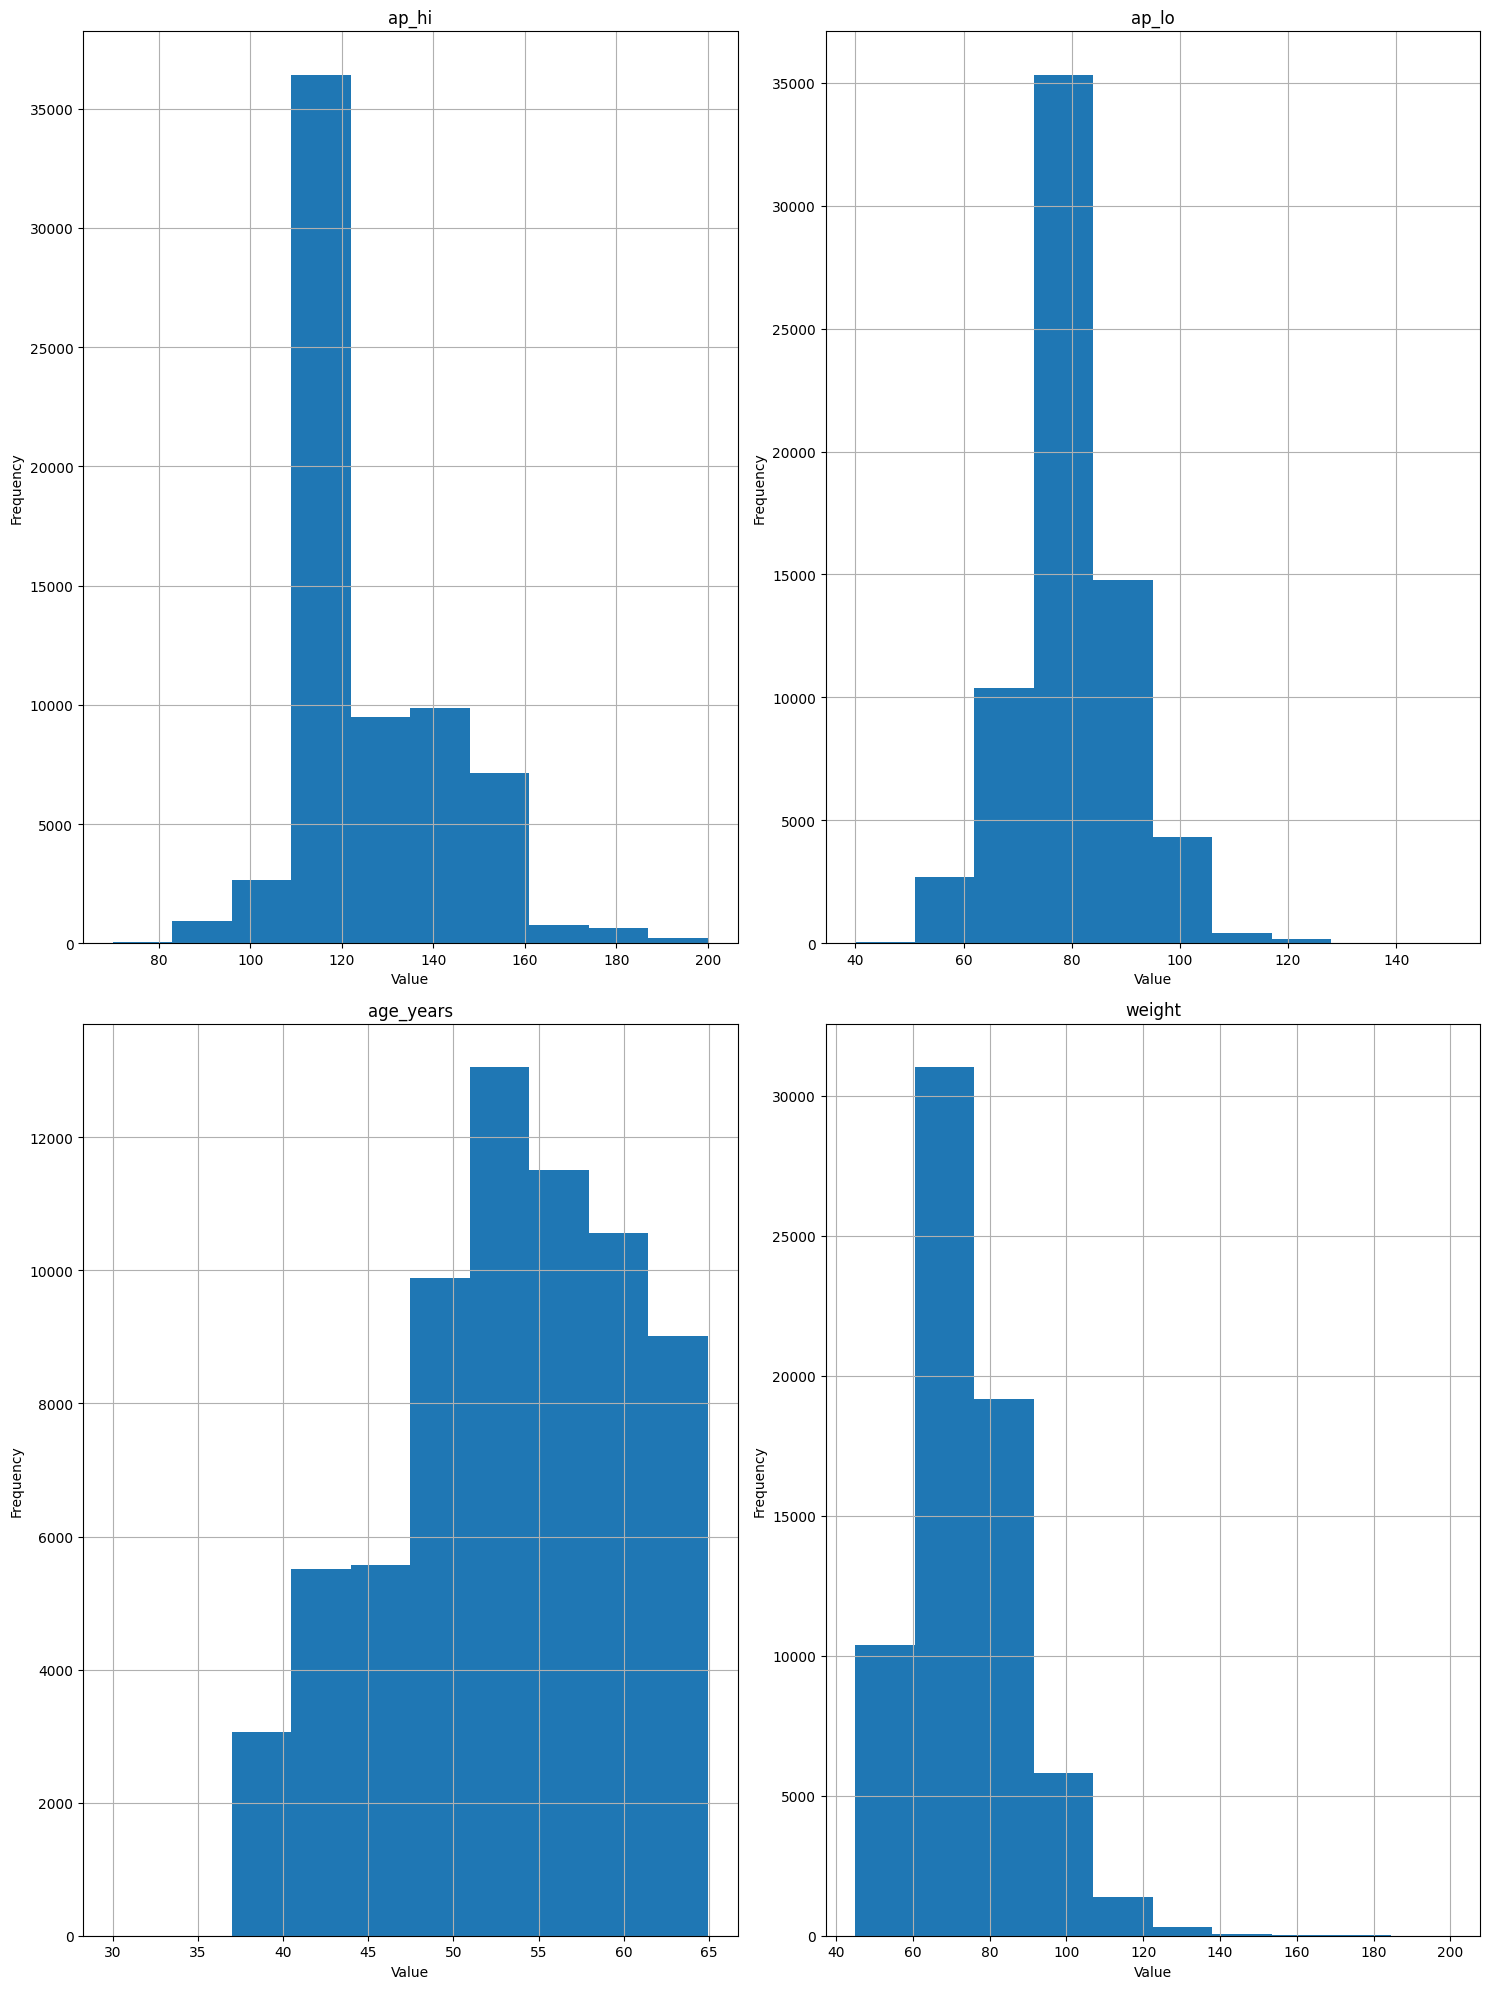

In [ ]:
# Histograms for each feature
numeric_cols = ["ap_hi", "ap_lo", "age_years", "weight"]
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(15, 20))

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()



 BMI seems to be fin with some exxtreme cases over 60; keeping since it is clinically possible
 BMI not used in training

## Gender based Histograms to see more imbalance

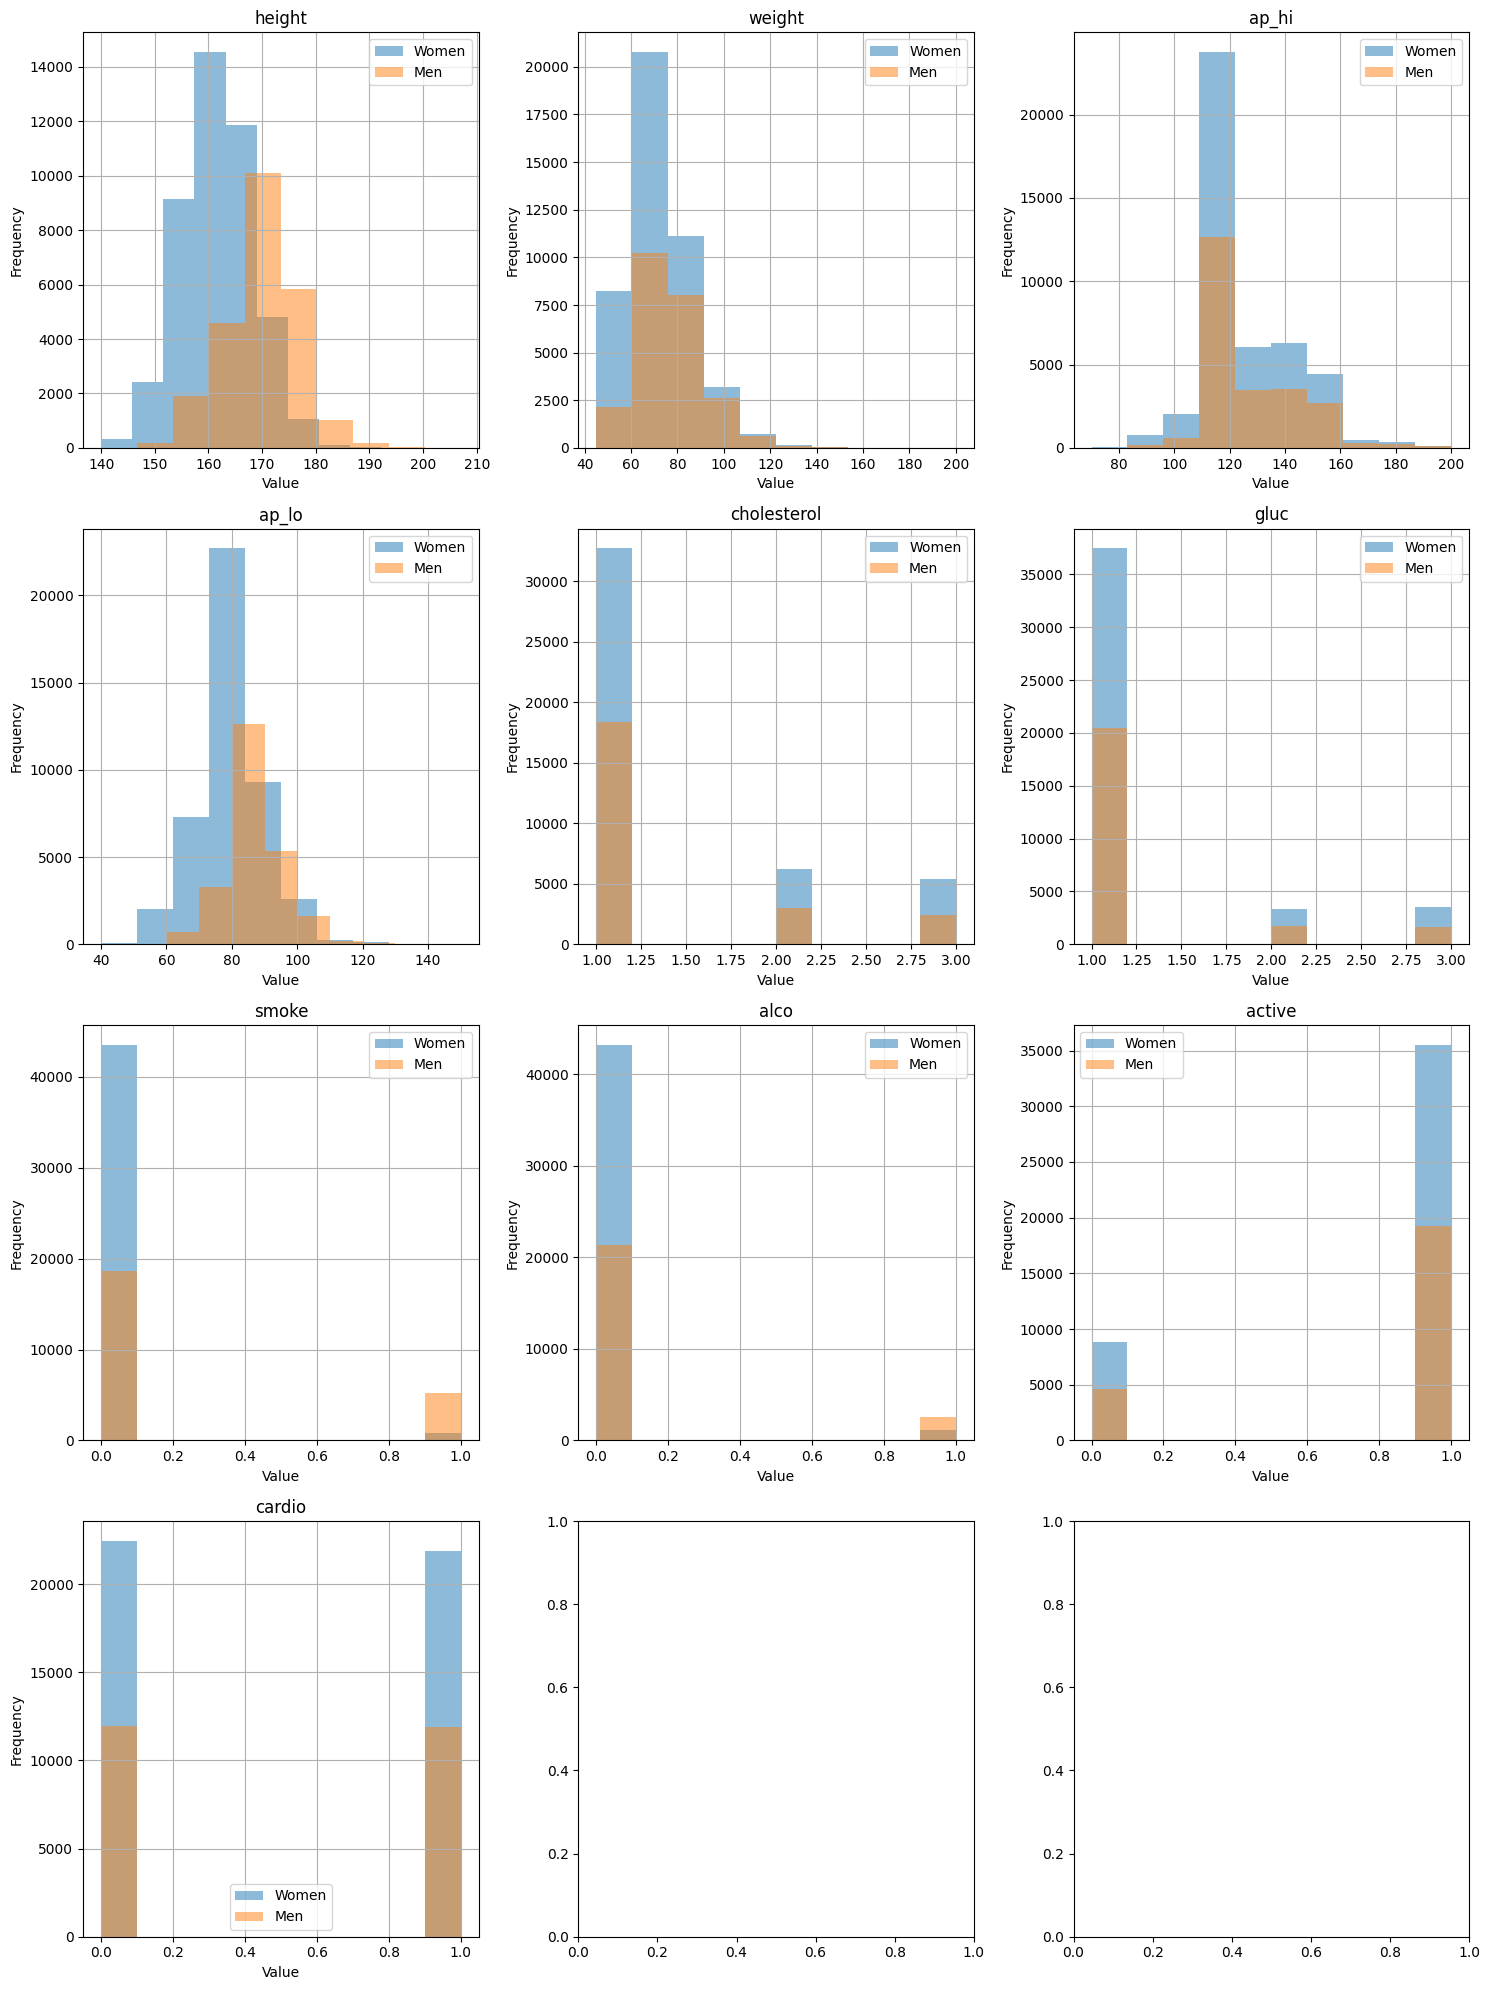

In [ ]:
# --- Histograms by gender ---
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

numeric_cols = [c for c in numeric_cols if c not in ["gender"]]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[df["gender"] == 0][col].hist(ax=axes[idx], alpha=0.5, label="Women")
    df[df["gender"] == 1][col].hist(ax=axes[idx], alpha=0.5, label="Men")

    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [58]:
# df=df.drop(columns="BMI")
# Dont want BMI in training
df.to_csv("data/processed/cardio_baseline_clean.csv", index=False)
print(df.columns)
# print(df.groupby("smoke")["cardio"].mean())
# print(df.groupby("alco")["cardio"].mean())
# print(df.groupby("gluc")["cardio"].mean())
# print(df.groupby("cholesterol")["cardio"].mean())
# print(df.groupby("gender")["cardio"].mean())
df_women = df[df["gender"] == 0]
# print(df_women.groupby(df_women["ap_hi"] < 130)["cardio"].mean())
# print(df_women.groupby(df_women["age_years"] < 50)["cardio"].mean())
df_gluc_chol = df[(df["gluc"] == 3)  & (df["cholesterol"] == 3)]
print(df_gluc_chol.columns)
print(df_gluc_chol.groupby("gender")["cardio"].value_counts())
# print(df_women.sum())
df_NoCVD_130below_women = df_women[(df_women["cardio"] == 0) & (df_women["ap_hi"] < 130)].copy()
# print(df_NoCVD_130below_women.mean())

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI'],
      dtype='str')
Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI'],
      dtype='str')
gender  cardio
0       1         1647
        0          737
1       1          666
        0          315
Name: count, dtype: int64


In [59]:
print(pd.crosstab(df["gender"], df["cholesterol"], normalize="index"))
print(pd.crosstab(df["gender"], df["gluc"], normalize="index"))

df.groupby("gender")[["smoke","alco","active"]].mean()

cholesterol         1         2         3
gender                                   
0            0.738399  0.139757  0.121844
1            0.771195  0.127044  0.101761
gluc           1         2         3
gender                              
0       0.845061  0.074898  0.080042
1       0.859623  0.071698  0.068679


,smoke,alco,active
gender,,,
0,0.017732,0.025199,0.801543
1,0.219287,0.106038,0.806415


* Cholesterol - Proportions similar across gender (women have slightly higher chol in dataset - very less difference)
* Glucose - also similar - More women in category 3, minor difference tho
* Smoking - Huge difference - 1.8 % women are smokers compared to 21.9% men being smokers (Men smoke 12x more often) - Model learns strong gender correlation
* Alcohol - 2.5% women drink alcohol, 10.6% men drink alcohol (Men drink 4x more)
**Note** - Since Smoking and Alcohol are self reported, due to social implications women are likely to underreport their habits so this is not as unreliable - might have to look into how to deal with this lol
* Physical Activity - Similar again

## Different Feature combinations
1. BSA 
2. Pulse pressure?
3. Health indicator maybe
4. Chol and glucose interaction since both are 0.45 correlated

Will need to see indicators



In [60]:
# # Adding BSA
# df["BSA"] = np.sqrt((df["height"] * df["weight"]) / 3600).round(2)
# # Keeping to 2 decimal places
# df['Pulse pressure'] = df['ap_hi'] - df['ap_lo']
# df["chol_gluc_interaction"] = df["cholesterol"] * df["gluc"]
# df = df.drop(columns = "height")


# df.to_csv("data/processed/cardio_bsa_pp.csv", index=False)